In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
import wikipedia
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')


nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

print("All imports completed successfully!")

All imports completed successfully!


In [2]:
article_title = "Hades II"

print(f"Fetching Wikipedia article: {article_title}")
try:
    wiki_article = wikipedia.page(article_title)
    raw_text = wiki_article.content
    print(f"\nArticle retrieved successfully!")
    print(f"Article length: {len(raw_text)} characters")
    print(f"Approximate word count: {len(raw_text.split())} words")
    print(f"\nFirst 300 characters of the article:")
    print(raw_text[:300])
except:
    print(f"Could not fetch {article_title}. Using sample text instead.")
    raw_text = ""

Fetching Wikipedia article: Hades II

Article retrieved successfully!
Article length: 15989 characters
Approximate word count: 2624 words

First 300 characters of the article:
Hades II is a 2025 roguelike action role-playing game developed and published by Supergiant Games, serving as a sequel to Hades (2020), making it their first project as a sequel. It was announced in December 2022 and was released in early access in May 2024 for Windows and in October 2024 for macOS,


In [3]:


def preprocess_text(text):
    """
    Preprocess raw text for Word2Vec training
    Steps:
    1. Tokenize into sentences
    2. Tokenize sentences into words
    3. Convert to lowercase
    4. Remove stopwords and punctuation
    5. Filter short words
    """

    sentences = sent_tokenize(text)
    

    processed_sentences = []
    stop_words = set(stopwords.words('english'))
    
    for sentence in sentences:

        words = simple_preprocess(sentence, deacc=True, min_len=3)

        words = [word for word in words if word not in stop_words]
        
        if len(words) > 2:  
            processed_sentences.append(words)
    
    return processed_sentences

print("Preprocessing text...")
sentences = preprocess_text(raw_text)

print(f"\nPreprocessing Results:")
print(f"Total sentences: {len(sentences)}")
print(f"Average words per sentence: {np.mean([len(s) for s in sentences]):.2f}")
print(f"Vocabulary size: {len(set(word for sent in sentences for word in sent))}")
print(f"\nFirst 5 preprocessed sentences:")
for i, sentence in enumerate(sentences[:5]):
    print(f"{i+1}. {sentence}")

Preprocessing text...

Preprocessing Results:
Total sentences: 111
Average words per sentence: 13.22
Vocabulary size: 799

First 5 preprocessed sentences:
1. ['hades', 'roguelike', 'action', 'role', 'playing', 'game', 'developed', 'published', 'supergiant', 'games', 'serving', 'sequel', 'hades', 'making', 'first', 'project', 'sequel']
2. ['announced', 'december', 'released', 'early', 'access', 'may', 'windows', 'october', 'macos', 'full', 'game', 'released', 'alongside', 'console', 'versions', 'nintendo', 'switch', 'nintendo', 'switch', 'september']
3. ['game', 'also', 'set', 'release', 'playstation', 'xbox', 'series', 'april']
4. ['game', 'follows', 'melinoe', 'princess', 'underworld', 'sister', 'zagreus', 'protagonist', 'first', 'game']
5. ['melinoe', 'aims', 'defeat', 'chronos', 'titan', 'time', 'aid', 'olympian', 'gods']


In [4]:

model = Word2Vec(
    sentences=sentences,
    vector_size=100,    
    window=5,           
    min_count=2,        
    sg=1,               
    negative=5,         
    epochs=10,
    workers=4
)

print("Model trained successfully!")
print(f"Vocabulary size: {len(model.wv)}")
print(f"Vector size: {model.vector_size}")
print(f"Window size: {model.window}")

Model trained successfully!
Vocabulary size: 237
Vector size: 100
Window size: 5


In [5]:


test_words = ['hades', 'melinoe', 'zagreus', 'olympian', 'chronos',
              'game', 'roguelike', 'supergiant', 'underworld', 'sequel']

print("=== Nearest Neighbors Evaluation ===\n")
for word in test_words:
    if word in model.wv:
        similar = model.wv.most_similar(word, topn=5)
        print(f"'{word}':")
        for neighbor, score in similar:
            print(f"   {neighbor:<20} {score:.4f}")
        print()
    else:
        print(f"'{word}' not in vocabulary\n")

=== Nearest Neighbors Evaluation ===

'hades':
   game                 0.8288
   melinoe              0.8144
   release              0.8037
   two                  0.7946
   access               0.7921

'melinoe':
   release              0.8649
   game                 0.8559
   early                0.8531
   access               0.8469
   characters           0.8272

'zagreus':
   game                 0.7694
   characters           0.7509
   early                0.7319
   next                 0.7274
   melinoe              0.7238

'olympian' not in vocabulary

'chronos':
   player               0.7359
   melinoe              0.7279
   hades                0.7241
   state                0.7202
   early                0.7186

'game':
   supergiant           0.8731
   melinoe              0.8559
   characters           0.8447
   release              0.8445
   early                0.8426

'roguelike':
   alternate            0.4474
   current              0.4207
   said                 0.4

In [6]:


word_pairs = [
    ('hades', 'zagreus'),
    ('melinoe', 'olympian'),
    ('game', 'roguelike'),
    ('chronos', 'titan'),
    ('underworld', 'olympian'),
]

print("=== Pairwise Similarity Scores ===\n")
for w1, w2 in word_pairs:
    if w1 in model.wv and w2 in model.wv:
        score = model.wv.similarity(w1, w2)
        print(f"  {w1} ↔ {w2}: {score:.4f}")
    else:
        print(f"  Skipped ({w1} or {w2} not in vocab)")

print("\n=== Analogy Test ===")
try:
    result = model.wv.most_similar(positive=['melinoe', 'game'], negative=['zagreus'], topn=3)
    print("melinoe + game - zagreus ≈")
    for word, score in result:
        print(f"   {word}: {score:.4f}")
except:
    print("Not enough vocabulary for analogy test.")

=== Pairwise Similarity Scores ===

  hades ↔ zagreus: 0.6879
  Skipped (melinoe or olympian not in vocab)
  game ↔ roguelike: 0.3270
  chronos ↔ titan: 0.6200
  Skipped (underworld or olympian not in vocab)

=== Analogy Test ===
melinoe + game - zagreus ≈
   release: 0.7942
   state: 0.7461
   supergiant: 0.7359


In [7]:


model_w10 = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=10,           
    min_count=2,
    sg=1,
    negative=5,
    epochs=10,
    workers=4
)

print("=== Window=5 vs Window=10 Comparison ===\n")
for word in ['hades', 'melinoe', 'game']:
    if word in model.wv and word in model_w10.wv:
        sim5  = model.wv.most_similar(word, topn=3)
        sim10 = model_w10.wv.most_similar(word, topn=3)
        print(f"'{word}'  window=5:  {[w for w,_ in sim5]}")
        print(f"'{word}'  window=10: {[w for w,_ in sim10]}")
        print()

=== Window=5 vs Window=10 Comparison ===

'hades'  window=5:  ['game', 'melinoe', 'release']
'hades'  window=10: ['game', 'access', 'chronos']

'melinoe'  window=5:  ['release', 'game', 'early']
'melinoe'  window=10: ['access', 'game', 'hades']

'game'  window=5:  ['supergiant', 'melinoe', 'characters']
'game'  window=10: ['hades', 'access', 'supergiant']



Visualizing 16 words: ['hades', 'melinoe', 'zagreus', 'chronos', 'game', 'roguelike', 'supergiant', 'underworld', 'sequel', 'playing', 'character', 'combat', 'story', 'titan', 'princess', 'magic']


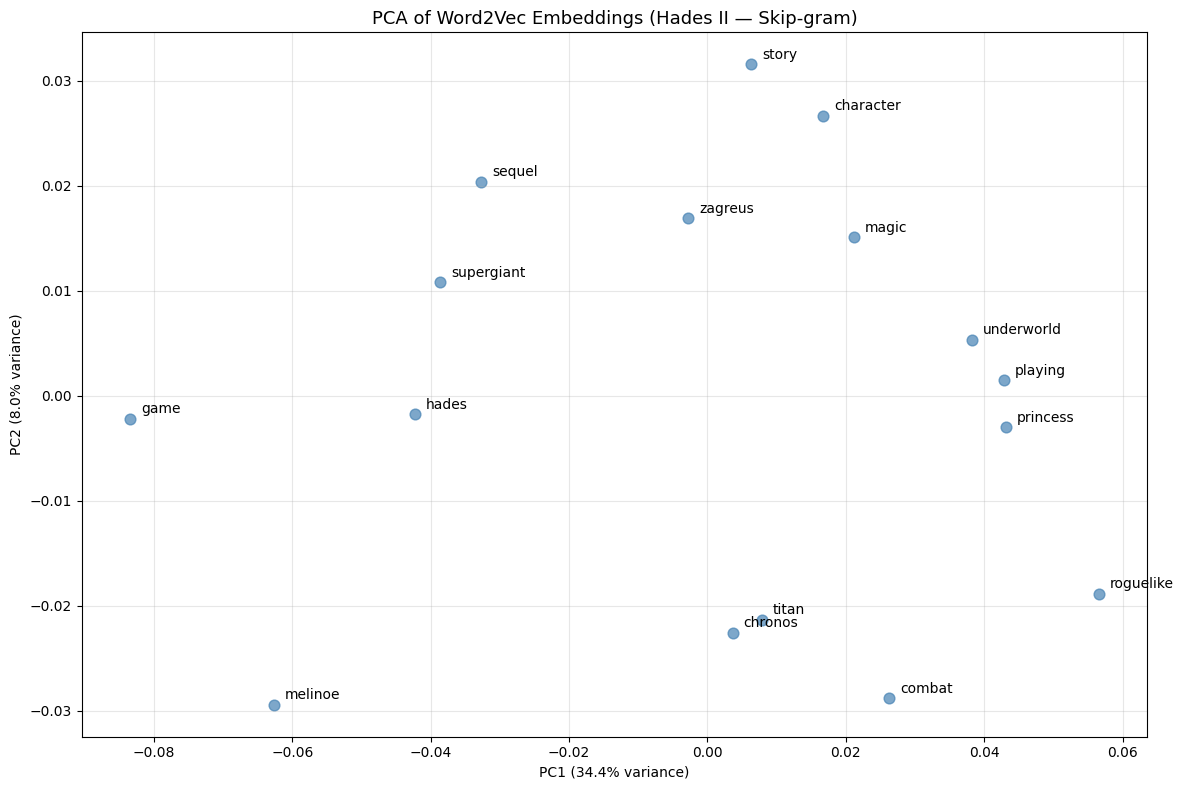

PCA plot saved as pca_word2vec.png


In [8]:


from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

viz_words = [
    'hades', 'melinoe', 'zagreus', 'olympian', 'chronos',
    'game', 'roguelike', 'supergiant', 'underworld', 'sequel',
    'action', 'playing', 'character', 'boss', 'combat',
    'story', 'titan', 'goddess', 'princess', 'magic'
]

viz_words = [w for w in viz_words if w in model.wv]
print(f"Visualizing {len(viz_words)} words: {viz_words}")

vectors = np.array([model.wv[w] for w in viz_words])

pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(12, 8))
plt.scatter(coords[:, 0], coords[:, 1], color='steelblue', s=60, alpha=0.7)

for i, word in enumerate(viz_words):
    plt.annotate(word, (coords[i, 0], coords[i, 1]),
                 textcoords="offset points", xytext=(8, 4),
                 fontsize=10)

plt.title("PCA of Word2Vec Embeddings (Hades II — Skip-gram)", fontsize=13)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pca_word2vec.png", dpi=150)
plt.show()
print("PCA plot saved as pca_word2vec.png")